# Daphnet FoG Dataset - Segmentation and LOSO Split

This notebook focuses on:
- Binary and multiclass label creation
- Pre-FoG annotation (0.5s before FoG)
- LOSO (Leave-One-Subject-Out) cross-validation splits

**Prerequisites:** Run `daphnet_EDA.ipynb` first to generate the processed dataset.

In [1]:
# Necessary imports
import sys
from pathlib import Path

# Add root directory to path
sys.path.insert(0, str(Path.cwd().parent.parent))

from loaders import DaphnetDatasetLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneGroupOut

sns.set_style('whitegrid')
%matplotlib inline

## Load Processed Dataset

In [2]:
# Load the dataset processed in EDA notebook
loader = DaphnetDatasetLoader('../../Datasets/Daphnet fog/dataset')
csv_path = '../../outputs/datasets_csv/daphnet_complete_dataset.csv'
df = loader.read_dataset(csv_path)

# Create subject and trial columns
df['subject'] = df['subject_id'].apply(lambda x: f'S{x:02d}')
df['trial'] = df['run_id'].apply(lambda x: f'R{x:02d}')

# Remove non-experiment data
df = df[df['annotation'] != 0].reset_index(drop=True)

print(f"Dataset loaded: {len(df):,} samples")
print(f"Subjects: {sorted(df['subject'].unique())}")
print(f"Trials per subject: {df.groupby('subject')['trial'].nunique().to_dict()}")

📂 Cargando dataset desde: daphnet_complete_dataset.csv
✅ Dataset cargado exitosamente
   📊 Dimensiones: (1917887, 16)
   💽 Memoria: 451.50 MB
Dataset loaded: 1,140,835 samples
Subjects: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10']
Trials per subject: {'S01': 2, 'S02': 2, 'S03': 3, 'S04': 1, 'S05': 2, 'S06': 2, 'S07': 2, 'S08': 1, 'S09': 1, 'S10': 1}


---
## Part 1: Binary and Multiclass Annotation

Creating labels for classification tasks:
- **Binary**: 0=No FoG, 1=FoG
- **Multiclass**: 0=No FoG, 1=FoG, 2=Pre-FoG (0.5s before FoG onset)

In [3]:
# Create binary and multiclass annotations
print("Creating binary and multiclass annotations...")

# Copy of dataframe to work with
df_processed = df.copy()

# 1. Binary Annotation: 0=No FoG, 1=FoG
# We consider FoG when annotation == 2 (Freeze)
df_processed['binary_label'] = (df_processed['annotation'] == 2).astype(int)

# 2. Multiclass Annotation: 0=No FoG, 1=FoG, 2=Pre-FoG
# Pre-FoG is defined as 0.5 seconds (32 samples at 64 Hz) before the first FoG
SAMPLING_RATE = 64  # Hz
PRE_FOG_WINDOW = int(0.5 * SAMPLING_RATE)  # 32 samples

# Initialize with original annotation
df_processed['multiclass_label'] = 0  # Default No FoG
df_processed.loc[df_processed['annotation'] == 2, 'multiclass_label'] = 1  # FoG

# Calculate Pre-FoG for each subject and trial
for subject in df_processed['subject_id'].unique():
    for trial in df_processed[df_processed['subject_id'] == subject]['trial'].unique():
        # Filter subject and trial data
        mask = (df_processed['subject_id'] == subject) & (df_processed['trial'] == trial)
        indices = df_processed[mask].index
        
        # Find transitions from No FoG to FoG (start of FoG episodes)
        fog_labels = df_processed.loc[indices, 'annotation'].values
        fog_starts = []
        
        for i in range(1, len(fog_labels)):
            # If it goes from no-FoG (0 or 1) to FoG (2)
            if fog_labels[i] == 2 and fog_labels[i-1] != 2:
                fog_starts.append(i)
        
        # Mark Pre-FoG for each FoG episode start
        for start_idx in fog_starts:
            # Calculate Pre-FoG range (32 samples before)
            pre_fog_start = max(0, start_idx - PRE_FOG_WINDOW)
            pre_fog_end = start_idx
            
            # Mark as Pre-FoG (2) only if they are not FoG
            pre_fog_indices = indices[pre_fog_start:pre_fog_end]
            # Only mark Pre-FoG where currently is No FoG (0)
            df_processed.loc[pre_fog_indices[df_processed.loc[pre_fog_indices, 'multiclass_label'] == 0], 'multiclass_label'] = 2

print("Annotations created!")
print(f"\nBinary Distribution:")
print(df_processed['binary_label'].value_counts().sort_index())
print(f"\nMulticlass Distribution:")
print(df_processed['multiclass_label'].value_counts().sort_index())
print(f"\nMulticlass Percentages:")
print(df_processed['multiclass_label'].value_counts(normalize=True).sort_index() * 100)

Creating binary and multiclass annotations...
Annotations created!

Binary Distribution:
binary_label
0    1030050
1     110785
Name: count, dtype: int64

Multiclass Distribution:
multiclass_label
0    1022466
1     110785
2       7584
Name: count, dtype: int64

Multiclass Percentages:
multiclass_label
0    89.624354
1     9.710870
2     0.664776
Name: proportion, dtype: float64


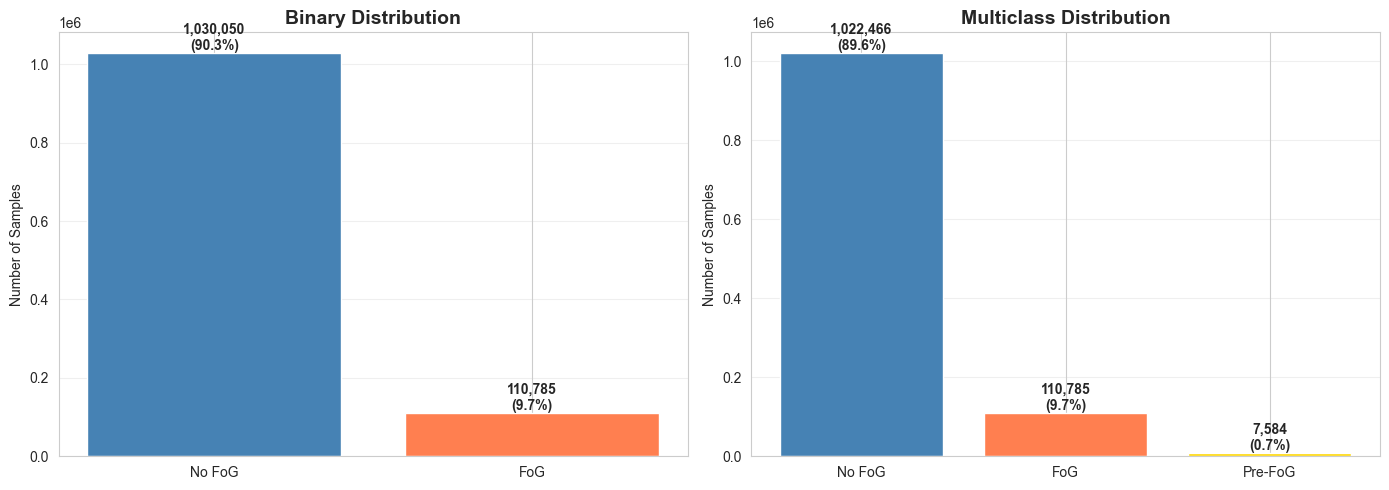

In [4]:
# Visualization of class distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary Distribution
binary_counts = df_processed['binary_label'].value_counts().sort_index()
axes[0].bar(['No FoG', 'FoG'], binary_counts.values, color=['steelblue', 'coral'])
axes[0].set_title('Binary Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(binary_counts.values):
    axes[0].text(i, v, f'{v:,}\n({v/len(df_processed)*100:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')

# Multiclass Distribution
multi_counts = df_processed['multiclass_label'].value_counts().sort_index()
axes[1].bar(['No FoG', 'FoG', 'Pre-FoG'], multi_counts.values, 
           color=['steelblue', 'coral', 'gold'])
axes[1].set_title('Multiclass Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Samples')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(multi_counts.values):
    axes[1].text(i, v, f'{v:,}\n({v/len(df_processed)*100:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

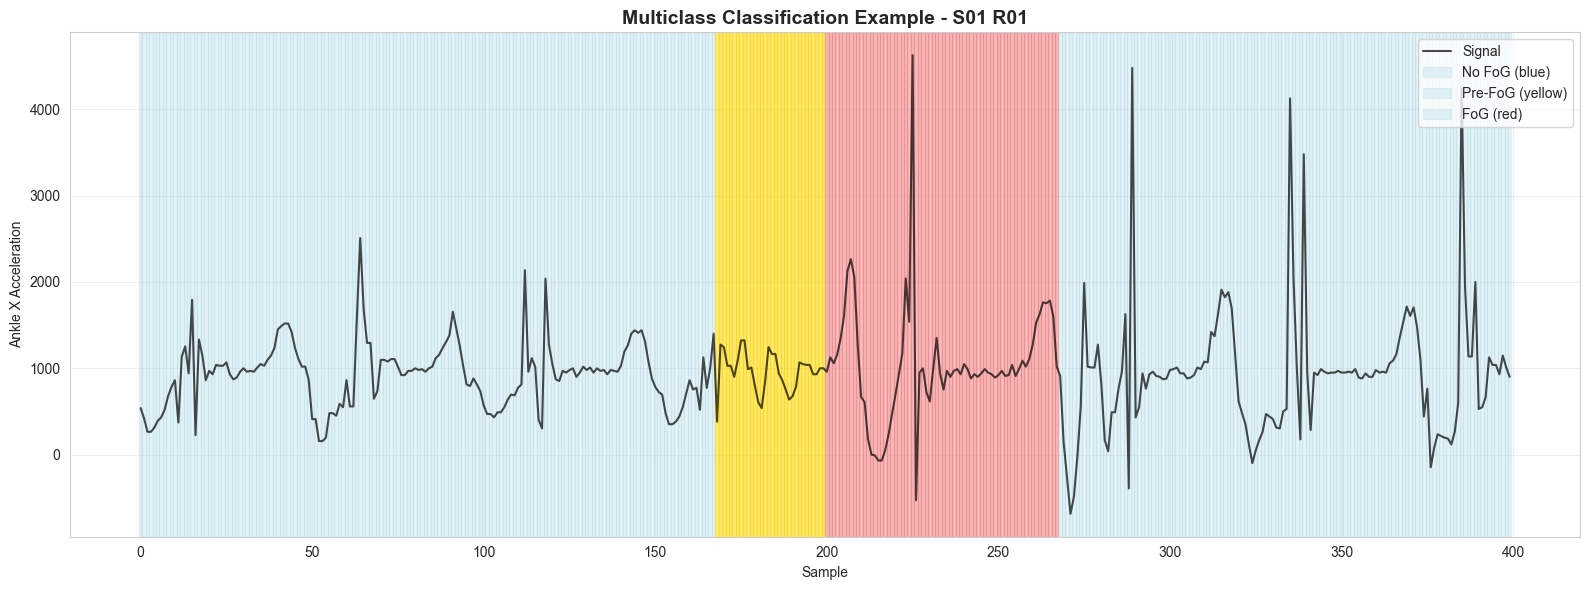

Window shown: samples 21546 to 21946
Distribution in this window:
multiclass_label
0    300
1     68
2     32
Name: count, dtype: int64


In [5]:
# Visualization of Pre-FoG example
# Search for a FoG episode to visualize the Pre-FoG
subject_example = 'S01'
trial_example = 'R01'

mask_example = (df_processed['subject'] == subject_example) & (df_processed['trial'] == trial_example)
example_data = df_processed[mask_example].reset_index(drop=True)

# Find a FoG episode
fog_indices = example_data[example_data['multiclass_label'] == 1].index
if len(fog_indices) > 0:
    # Take a range around the first FoG episode
    fog_start = fog_indices[0]
    window_start = max(0, fog_start - 200)
    window_end = min(len(example_data), fog_start + 200)
    
    window_data = example_data.iloc[window_start:window_end]
    
    # Visualize
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Plot ankle acceleration (X axis as example)
    ax.plot(window_data.index - window_start, window_data['ankle_acc_vertical'], 
           label='Ankle X', color='black', linewidth=1.5, alpha=0.7)
    
    # Color background according to class
    no_fog = window_data[window_data['multiclass_label'] == 0]
    fog = window_data[window_data['multiclass_label'] == 1]
    pre_fog = window_data[window_data['multiclass_label'] == 2]
    
    for idx in no_fog.index:
        ax.axvspan(idx - window_start - 0.5, idx - window_start + 0.5, 
                  color='lightblue', alpha=0.3)
    for idx in pre_fog.index:
        ax.axvspan(idx - window_start - 0.5, idx - window_start + 0.5, 
                  color='gold', alpha=0.5)
    for idx in fog.index:
        ax.axvspan(idx - window_start - 0.5, idx - window_start + 0.5, 
                  color='lightcoral', alpha=0.5)
    
    ax.set_title(f'Multiclass Classification Example - {subject_example} {trial_example}', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Ankle X Acceleration')
    ax.legend(['Signal', 'No FoG (blue)', 'Pre-FoG (yellow)', 'FoG (red)'], 
             loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Window shown: samples {window_start} to {window_end}")
    print(f"Distribution in this window:")
    print(window_data['multiclass_label'].value_counts().sort_index())
else:
    print("No FoG episodes found in this trial")

---
## Part 2: LOSO (Leave-One-Subject-Out) Split

Subject-independent validation: Each subject is used as test set once while training on all other subjects.

In [6]:

feature_columns = [col for col in df_processed.columns 
                  if any(sensor in col for sensor in ['ankle', 'thigh', 'trunk'])]

X = df_processed[feature_columns].values
y_binary = df_processed['binary_label'].values
y_multiclass = df_processed['multiclass_label'].values
groups = df_processed['subject'].values

# Initialize LOSO
logo = LeaveOneGroupOut()
n_splits = logo.get_n_splits(groups=groups)

print(f"\nNumber of LOSO splits: {n_splits}")
print(f"Features: {len(feature_columns)} columns")
print(f"Feature columns: {feature_columns}")

# Create dictionary to store splits
loso_splits = []

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y_multiclass, groups)):
    test_subject = groups[test_idx][0]  # Test subject
    
    split_info = {
        'fold': fold,
        'test_subject': test_subject,
        'train_idx': train_idx,
        'test_idx': test_idx,
        'train_size': len(train_idx),
        'test_size': len(test_idx)
    }
    loso_splits.append(split_info)
    
    print(f"\nFold {fold}: Test Subject = {test_subject}")
    print(f"  Train samples: {len(train_idx):,} | Test samples: {len(test_idx):,}")
    print(f"  Train FoG distribution (multiclass): {np.bincount(y_multiclass[train_idx])}")
    print(f"  Test FoG distribution (multiclass): {np.bincount(y_multiclass[test_idx])}")

print(f"\n✓ {n_splits} LOSO splits created successfully!")


Number of LOSO splits: 10
Features: 9 columns
Feature columns: ['ankle_acc_forward', 'ankle_acc_vertical', 'ankle_acc_lateral', 'thigh_acc_forward', 'thigh_acc_vertical', 'thigh_acc_lateral', 'trunk_acc_forward', 'trunk_acc_vertical', 'trunk_acc_lateral']

Fold 0: Test Subject = S01
  Train samples: 1,019,232 | Test samples: 121,603
  Train FoG distribution (multiclass): [908293 104091   6848]
  Test FoG distribution (multiclass): [114173   6694    736]

Fold 1: Test Subject = S02
  Train samples: 1,050,273 | Test samples: 90,562
  Train FoG distribution (multiclass): [944281  99176   6816]
  Test FoG distribution (multiclass): [78185 11609   768]

Fold 2: Test Subject = S03
  Train samples: 1,012,191 | Test samples: 128,644
  Train FoG distribution (multiclass): [913730  92445   6016]
  Test FoG distribution (multiclass): [108736  18340   1568]

Fold 3: Test Subject = S04
  Train samples: 1,008,353 | Test samples: 132,482
  Train FoG distribution (multiclass): [889984 110785   7584]


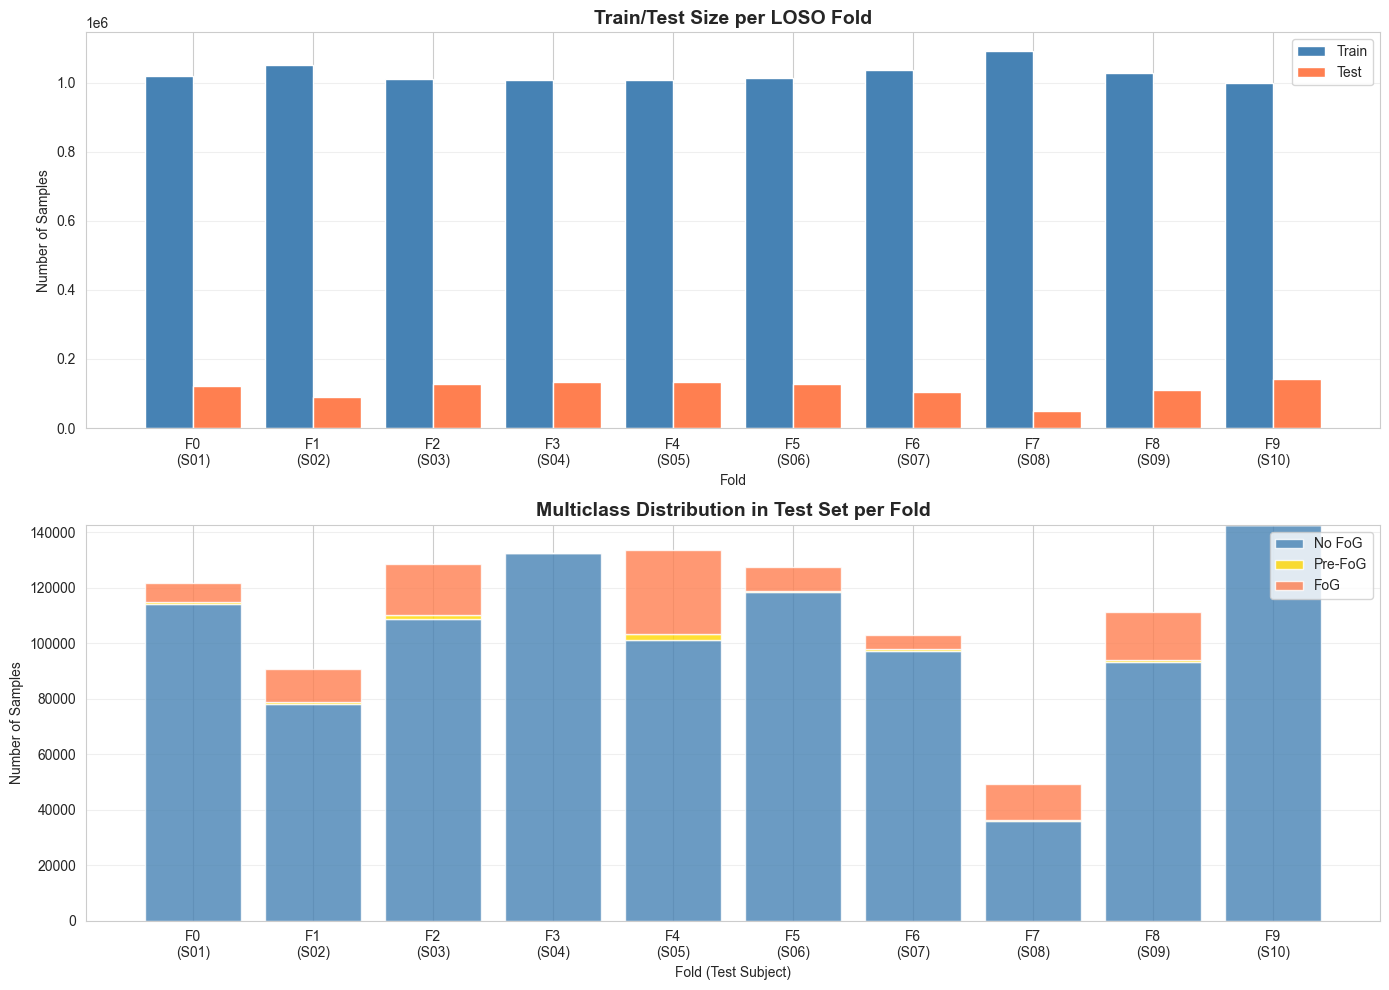

In [7]:
# Visualization of sample distribution per LOSO fold
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Train/test size per fold
train_sizes = [split['train_size'] for split in loso_splits]
test_sizes = [split['test_size'] for split in loso_splits]
test_subjects = [split['test_subject'] for split in loso_splits]

x_pos = np.arange(len(loso_splits))
axes[0].bar(x_pos - 0.2, train_sizes, 0.4, label='Train', color='steelblue')
axes[0].bar(x_pos + 0.2, test_sizes, 0.4, label='Test', color='coral')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Train/Test Size per LOSO Fold', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f"F{i}\n({s})" for i, s in enumerate(test_subjects)])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Multiclass distribution in test set
fog_counts_test = []
no_fog_counts_test = []
pre_fog_counts_test = []

for split in loso_splits:
    test_labels = y_multiclass[split['test_idx']]
    counts = np.bincount(test_labels, minlength=3)
    no_fog_counts_test.append(counts[0])
    fog_counts_test.append(counts[1])
    pre_fog_counts_test.append(counts[2])

axes[1].bar(x_pos, no_fog_counts_test, label='No FoG', color='steelblue', alpha=0.8)
axes[1].bar(x_pos, pre_fog_counts_test, bottom=no_fog_counts_test, 
           label='Pre-FoG', color='gold', alpha=0.8)
axes[1].bar(x_pos, fog_counts_test, 
           bottom=np.array(no_fog_counts_test) + np.array(pre_fog_counts_test),
           label='FoG', color='coral', alpha=0.8)
axes[1].set_xlabel('Fold (Test Subject)')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Multiclass Distribution in Test Set per Fold', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f"F{i}\n({s})" for i, s in enumerate(test_subjects)])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [8]:
def create_sliding_windows(data, labels, window_size, overlap=0.5, sampling_rate=64):
    """
    Creates sliding windows from time series data.
    
    Parameters:
    -----------
    data : numpy.ndarray
        Feature data (n_samples, n_features)
    labels : numpy.ndarray
        Labels for each sample (n_samples,)
    window_size : float
        Window size in seconds
    overlap : float
        Overlap proportion between windows (0.0 to 1.0)
    sampling_rate : int
        Sampling frequency in Hz
    
    Returns:
    --------
    windows : numpy.ndarray
        Array of windows (n_windows, window_samples, n_features)
    window_labels : numpy.ndarray
        Labels for each window (using majority voting)
    """
    # Calculate window size in samples
    window_samples = int(window_size * sampling_rate)
    step_size = int(window_samples * (1 - overlap))
    
    windows = []
    window_labels = []
    
    # Create sliding windows
    for start in range(0, len(data) - window_samples + 1, step_size):
        end = start + window_samples
        
        # Extract window
        window = data[start:end]
        window_label_segment = labels[start:end]
        
        # Window label: majority voting
        window_label = np.bincount(window_label_segment).argmax()
        
        windows.append(window)
        window_labels.append(window_label)
    
    return np.array(windows), np.array(window_labels)


def create_windows_per_subject(df_subset, feature_cols, label_col, window_size, overlap=0.5):
    """
    Creates sliding windows per subject and trial to maintain temporal continuity.
    
    Parameters:
    -----------
    df_subset : pandas.DataFrame
        Subset of DataFrame (train or test)
    feature_cols : list
        List of feature columns
    label_col : str
        Name of the label column
    window_size : float
        Window size in seconds
    overlap : float
        Overlap proportion between windows
    
    Returns:
    --------
    windows : numpy.ndarray
        Array of windows
    labels : numpy.ndarray
        Window labels
    subjects : numpy.ndarray
        Subject corresponding to each window
    """
    all_windows = []
    all_labels = []
    all_subjects = []
    
    for subject in df_subset['subject'].unique():
        for trial in df_subset[df_subset['subject'] == subject]['trial'].unique():
            # Filter subject and trial data
            mask = (df_subset['subject'] == subject) & (df_subset['trial'] == trial)
            subject_data = df_subset[mask]
            
            # Extract features and labels
            X_subject = subject_data[feature_cols].values
            y_subject = subject_data[label_col].values
            
            # Create windows for this subject/trial
            windows, labels = create_sliding_windows(
                X_subject, y_subject, window_size, overlap
            )
            
            if len(windows) > 0:
                all_windows.append(windows)
                all_labels.append(labels)
                all_subjects.extend([subject] * len(windows))
    
    # Concatenate all windows
    if len(all_windows) > 0:
        all_windows = np.concatenate(all_windows, axis=0)
        all_labels = np.concatenate(all_labels, axis=0)
        all_subjects = np.array(all_subjects)
    else:
        all_windows = np.array([])
        all_labels = np.array([])
        all_subjects = np.array([])
    
    return all_windows, all_labels, all_subjects

print("✓ Sliding window functions defined!")

✓ Sliding window functions defined!


---
## Part 3: Sliding Windows Within LOSO Folds

Creating sliding windows **within each LOSO fold** to prevent data leakage:
- Windows are created separately for train and test sets
- No information from test subjects leaks into training windows
- Window size: 4 seconds (256 samples at 64 Hz)
- Overlap: 50%

In [9]:
# Configuration for sliding windows
WINDOW_SIZE_SEC = 4  # seconds
OVERLAP = 0.5  # 50% overlap
SAMPLING_RATE = 64  # Hz

print(f"Window Configuration:")
print(f"  - Window size: {WINDOW_SIZE_SEC} seconds ({WINDOW_SIZE_SEC * SAMPLING_RATE} samples)")
print(f"  - Overlap: {OVERLAP*100}%")
print(f"  - Step size: {int(WINDOW_SIZE_SEC * SAMPLING_RATE * (1-OVERLAP))} samples")

# Create windows for each LOSO fold
loso_window_splits_binary = []
loso_window_splits_multiclass = []

print(f"\n{'='*60}")
print(f"Creating windows for each LOSO fold...")
print(f"{'='*60}")

for fold_idx, split in enumerate(loso_splits):
    print(f"\n--- Fold {fold_idx} (Test Subject: {split['test_subject']}) ---")
    
    # Get train and test data for this fold
    train_idx = split['train_idx']
    test_idx = split['test_idx']
    
    df_train = df_processed.iloc[train_idx].reset_index(drop=True)
    df_test = df_processed.iloc[test_idx].reset_index(drop=True)
    
    # Create windows for BINARY classification
    X_train_win_bin, y_train_win_bin, subj_train_bin = create_windows_per_subject(
        df_train, feature_columns, 'binary_label', WINDOW_SIZE_SEC, OVERLAP
    )
    X_test_win_bin, y_test_win_bin, subj_test_bin = create_windows_per_subject(
        df_test, feature_columns, 'binary_label', WINDOW_SIZE_SEC, OVERLAP
    )
    
    # Create windows for MULTICLASS classification
    X_train_win_multi, y_train_win_multi, subj_train_multi = create_windows_per_subject(
        df_train, feature_columns, 'multiclass_label', WINDOW_SIZE_SEC, OVERLAP
    )
    X_test_win_multi, y_test_win_multi, subj_test_multi = create_windows_per_subject(
        df_test, feature_columns, 'multiclass_label', WINDOW_SIZE_SEC, OVERLAP
    )
    
    # Store binary window split
    loso_window_splits_binary.append({
        'fold': fold_idx,
        'test_subject': split['test_subject'],
        'X_train': X_train_win_bin,
        'X_test': X_test_win_bin,
        'y_train': y_train_win_bin,
        'y_test': y_test_win_bin,
        'subjects_train': subj_train_bin,
        'subjects_test': subj_test_bin,
        'train_dist': np.bincount(y_train_win_bin, minlength=2),
        'test_dist': np.bincount(y_test_win_bin, minlength=2)
    })
    
    # Store multiclass window split
    loso_window_splits_multiclass.append({
        'fold': fold_idx,
        'test_subject': split['test_subject'],
        'X_train': X_train_win_multi,
        'X_test': X_test_win_multi,
        'y_train': y_train_win_multi,
        'y_test': y_test_win_multi,
        'subjects_train': subj_train_multi,
        'subjects_test': subj_test_multi,
        'train_dist': np.bincount(y_train_win_multi, minlength=3),
        'test_dist': np.bincount(y_test_win_multi, minlength=3)
    })
    
    print(f"Binary Windows:")
    print(f"  Train: {len(X_train_win_bin)} windows | Test: {len(X_test_win_bin)} windows")
    print(f"  Train dist: {np.bincount(y_train_win_bin, minlength=2)}")
    print(f"  Test dist: {np.bincount(y_test_win_bin, minlength=2)}")
    
    print(f"Multiclass Windows:")
    print(f"  Train: {len(X_train_win_multi)} windows | Test: {len(X_test_win_multi)} windows")
    print(f"  Train dist: {np.bincount(y_train_win_multi, minlength=3)}")
    print(f"  Test dist: {np.bincount(y_test_win_multi, minlength=3)}")

print(f"\n{'='*60}")
print(f"✓ All {len(loso_splits)} folds processed successfully!")
print(f"✓ Binary windows: {len(loso_window_splits_binary)} folds")
print(f"✓ Multiclass windows: {len(loso_window_splits_multiclass)} folds")
print(f"{'='*60}")

Window Configuration:
  - Window size: 4 seconds (256 samples)
  - Overlap: 50.0%
  - Step size: 128 samples

Creating windows for each LOSO fold...

--- Fold 0 (Test Subject: S01) ---
Binary Windows:
  Train: 7947 windows | Test: 948 windows
  Train dist: [7140  807]
  Test dist: [903  45]
Multiclass Windows:
  Train: 7947 windows | Test: 948 windows
  Train dist: [7113  834    0]
  Test dist: [899  49   0]

--- Fold 1 (Test Subject: S02) ---
Binary Windows:
  Train: 8190 windows | Test: 705 windows
  Train dist: [7430  760]
  Test dist: [613  92]
Multiclass Windows:
  Train: 8190 windows | Test: 705 windows
  Train dist: [7405  785    0]
  Test dist: [607  98   0]

--- Fold 2 (Test Subject: S03) ---
Binary Windows:
  Train: 7893 windows | Test: 1002 windows
  Train dist: [7185  708]
  Test dist: [858 144]
Multiclass Windows:
  Train: 7893 windows | Test: 1002 windows
  Train dist: [7159  734    0]
  Test dist: [853 149   0]

--- Fold 3 (Test Subject: S04) ---
Binary Windows:
  Train:

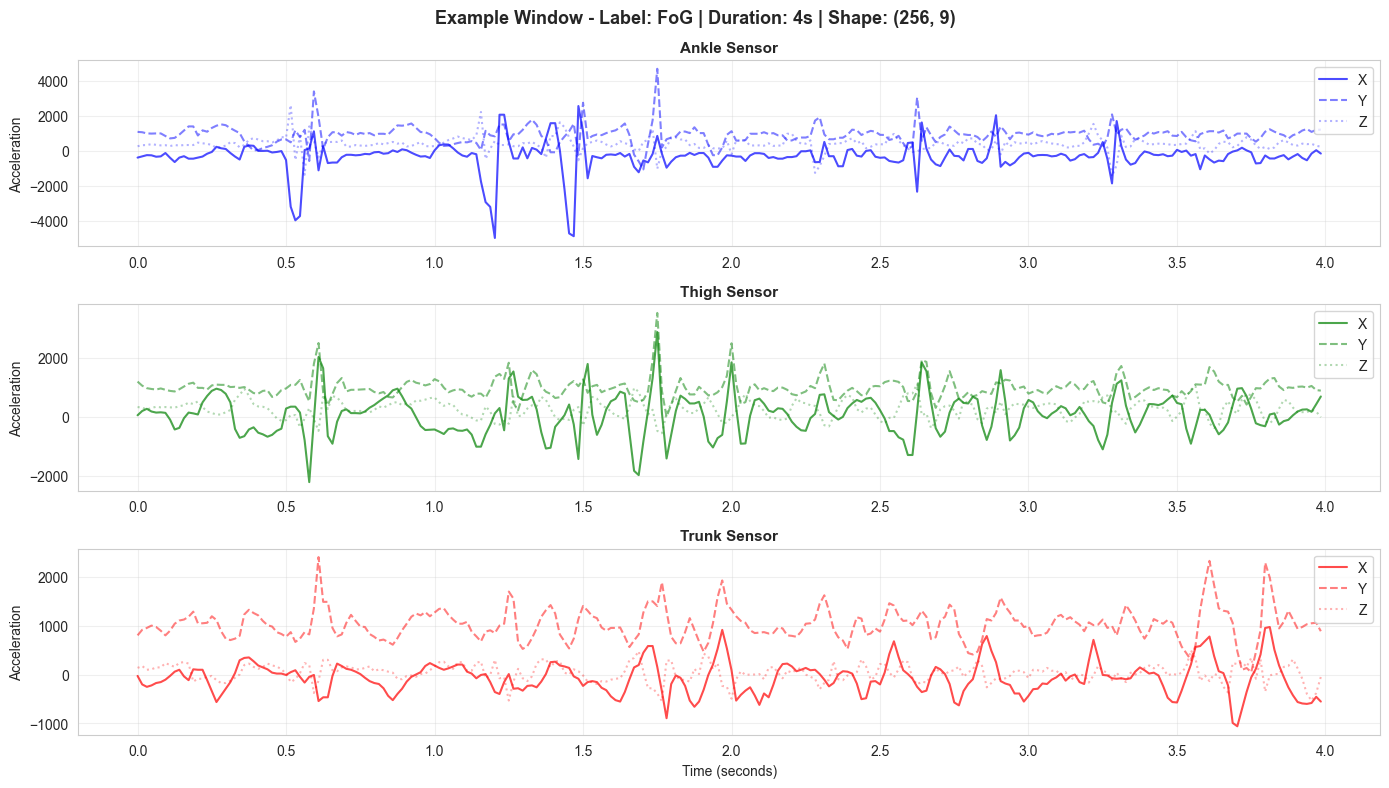

Window details:
  Shape: (256, 9) (time_steps, features)
  Time steps: 256 samples = 4.0s
  Features: 9 = 3 sensors × 3 axes


In [10]:
# Visualize an example window from Fold 0
fold_0 = loso_window_splits_multiclass[0]

# Find a FoG window in test set
fog_indices = np.where(fold_0['y_test'] == 1)[0]
if len(fog_indices) > 0:
    example_window = fold_0['X_test'][fog_indices[0]]
    example_label = fold_0['y_test'][fog_indices[0]]
    
    label_names = {0: 'No FoG', 1: 'FoG', 2: 'Pre-FoG'}
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 8))
    sensors = ['Ankle', 'Thigh', 'Trunk']
    colors = ['blue', 'green', 'red']
    
    time_axis = np.arange(example_window.shape[0]) / SAMPLING_RATE
    
    for idx in range(3):
        # Get X, Y, Z for this sensor
        sensor_data = example_window[:, idx*3:(idx+1)*3]
        
        axes[idx].plot(time_axis, sensor_data[:, 0], label='X', 
                      color=colors[idx], alpha=0.7, linewidth=1.5)
        axes[idx].plot(time_axis, sensor_data[:, 1], label='Y', 
                      color=colors[idx], alpha=0.5, linewidth=1.5, linestyle='--')
        axes[idx].plot(time_axis, sensor_data[:, 2], label='Z', 
                      color=colors[idx], alpha=0.3, linewidth=1.5, linestyle=':')
        
        axes[idx].set_title(f'{sensors[idx]} Sensor', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('Acceleration')
        axes[idx].legend(loc='upper right')
        axes[idx].grid(True, alpha=0.3)
    
    axes[2].set_xlabel('Time (seconds)')
    plt.suptitle(f'Example Window - Label: {label_names[example_label]} | Duration: {WINDOW_SIZE_SEC}s | Shape: {example_window.shape}', 
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"Window details:")
    print(f"  Shape: {example_window.shape} (time_steps, features)")
    print(f"  Time steps: {example_window.shape[0]} samples = {example_window.shape[0]/SAMPLING_RATE}s")
    print(f"  Features: {example_window.shape[1]} = 3 sensors × 3 axes")
else:
    print("No FoG windows found in test set of Fold 0")

### Visualize Example Window

In [11]:
# Summary statistics
print("="*70)
print("WINDOW SUMMARY STATISTICS")
print("="*70)

# Binary windows
total_train_bin = sum([split['X_train'].shape[0] for split in loso_window_splits_binary])
total_test_bin = sum([split['X_test'].shape[0] for split in loso_window_splits_binary])

print(f"\nBINARY Classification:")
print(f"  Total train windows: {total_train_bin:,}")
print(f"  Total test windows: {total_test_bin:,}")
print(f"  Avg train per fold: {total_train_bin/len(loso_window_splits_binary):.0f}")
print(f"  Avg test per fold: {total_test_bin/len(loso_window_splits_binary):.0f}")

# Multiclass windows
total_train_multi = sum([split['X_train'].shape[0] for split in loso_window_splits_multiclass])
total_test_multi = sum([split['X_test'].shape[0] for split in loso_window_splits_multiclass])

print(f"\nMULTICLASS Classification:")
print(f"  Total train windows: {total_train_multi:,}")
print(f"  Total test windows: {total_test_multi:,}")
print(f"  Avg train per fold: {total_train_multi/len(loso_window_splits_multiclass):.0f}")
print(f"  Avg test per fold: {total_test_multi/len(loso_window_splits_multiclass):.0f}")

# Window shape
example_fold = loso_window_splits_multiclass[0]
print(f"\nWindow Shape (samples, features):")
print(f"  {example_fold['X_train'].shape[1:]} → {example_fold['X_train'].shape[1]} samples × {example_fold['X_train'].shape[2]} features")
print(f"  = {WINDOW_SIZE_SEC}s × 64Hz × 9 accelerometer channels")

print("="*70)

WINDOW SUMMARY STATISTICS

BINARY Classification:
  Total train windows: 80,055
  Total test windows: 8,895
  Avg train per fold: 8006
  Avg test per fold: 890

MULTICLASS Classification:
  Total train windows: 80,055
  Total test windows: 8,895
  Avg train per fold: 8006
  Avg test per fold: 890

Window Shape (samples, features):
  (256, 9) → 256 samples × 9 features
  = 4s × 64Hz × 9 accelerometer channels


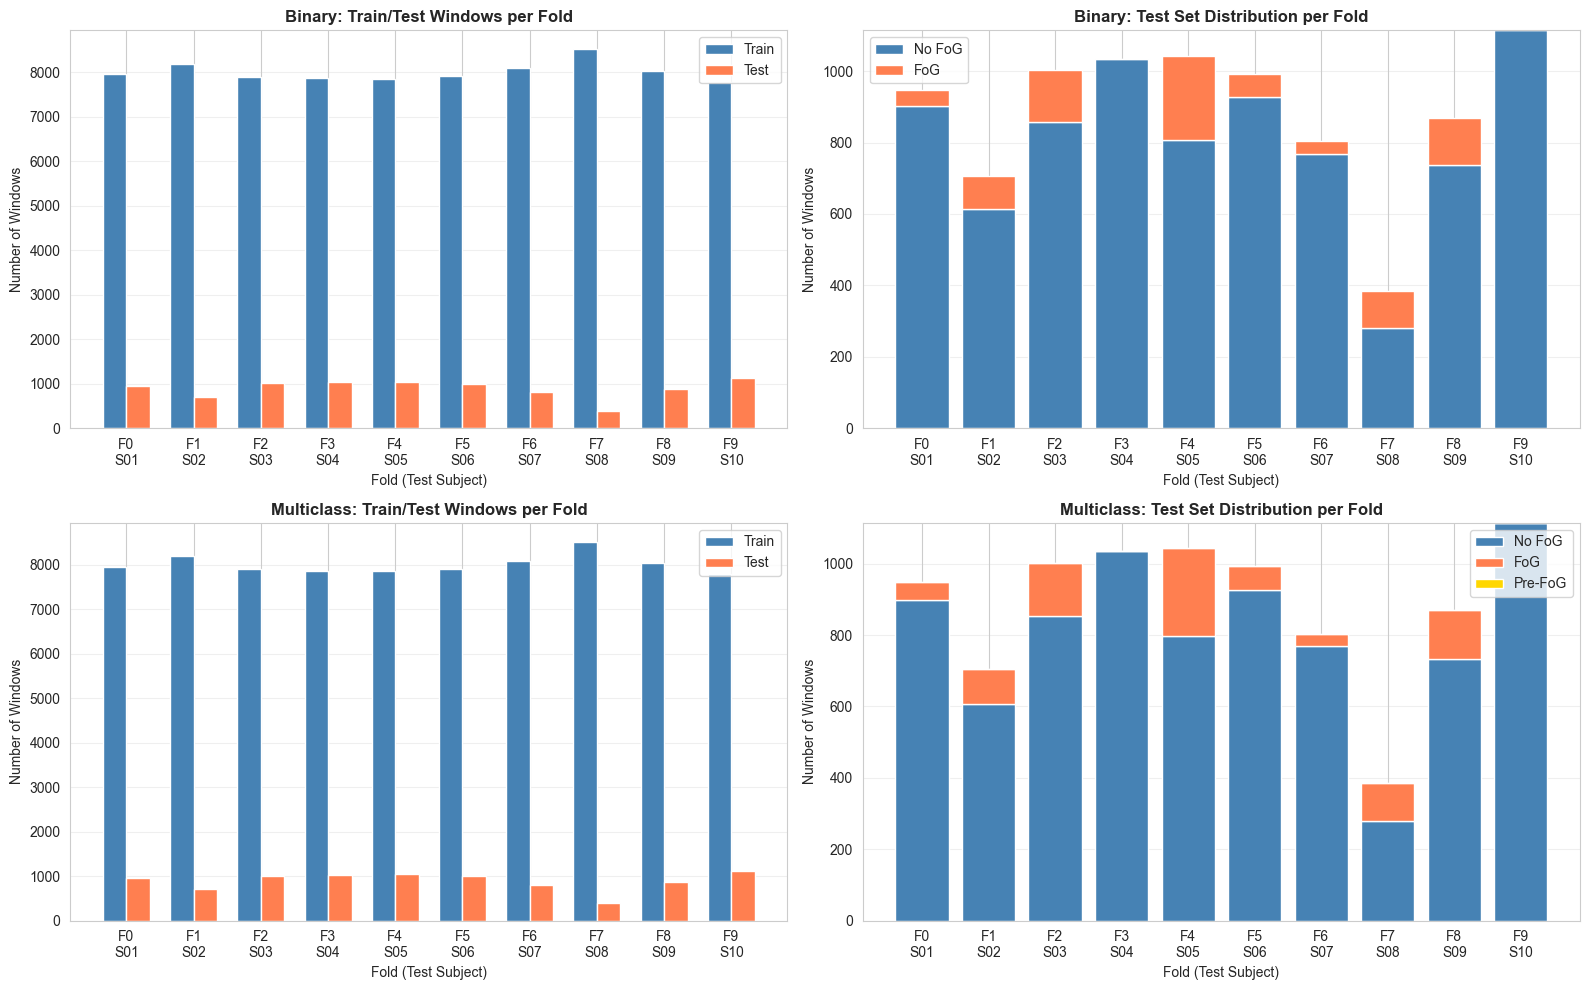

In [12]:
# Visualization of window distributions across folds
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Binary: Train/Test window counts per fold
train_counts_bin = [split['X_train'].shape[0] for split in loso_window_splits_binary]
test_counts_bin = [split['X_test'].shape[0] for split in loso_window_splits_binary]
test_subjects = [split['test_subject'] for split in loso_window_splits_binary]

x = np.arange(len(loso_window_splits_binary))
width = 0.35
axes[0, 0].bar(x - width/2, train_counts_bin, width, label='Train', color='steelblue')
axes[0, 0].bar(x + width/2, test_counts_bin, width, label='Test', color='coral')
axes[0, 0].set_xlabel('Fold (Test Subject)')
axes[0, 0].set_ylabel('Number of Windows')
axes[0, 0].set_title('Binary: Train/Test Windows per Fold', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels([f"F{i}\n{s}" for i, s in enumerate(test_subjects)])
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Binary: Test set class distribution per fold
for i, split in enumerate(loso_window_splits_binary):
    test_dist = split['test_dist']
    bottom = 0
    colors = ['steelblue', 'coral']
    labels = ['No FoG', 'FoG']
    for cls_idx, count in enumerate(test_dist):
        axes[0, 1].bar(i, count, bottom=bottom, color=colors[cls_idx], 
                      label=labels[cls_idx] if i == 0 else "")
        bottom += count
axes[0, 1].set_xlabel('Fold (Test Subject)')
axes[0, 1].set_ylabel('Number of Windows')
axes[0, 1].set_title('Binary: Test Set Distribution per Fold', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(range(len(loso_window_splits_binary)))
axes[0, 1].set_xticklabels([f"F{i}\n{s}" for i, s in enumerate(test_subjects)])
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Multiclass: Train/Test window counts per fold
train_counts_multi = [split['X_train'].shape[0] for split in loso_window_splits_multiclass]
test_counts_multi = [split['X_test'].shape[0] for split in loso_window_splits_multiclass]

axes[1, 0].bar(x - width/2, train_counts_multi, width, label='Train', color='steelblue')
axes[1, 0].bar(x + width/2, test_counts_multi, width, label='Test', color='coral')
axes[1, 0].set_xlabel('Fold (Test Subject)')
axes[1, 0].set_ylabel('Number of Windows')
axes[1, 0].set_title('Multiclass: Train/Test Windows per Fold', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels([f"F{i}\n{s}" for i, s in enumerate(test_subjects)])
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Multiclass: Test set class distribution per fold
for i, split in enumerate(loso_window_splits_multiclass):
    test_dist = split['test_dist']
    bottom = 0
    colors = ['steelblue', 'coral', 'gold']
    labels = ['No FoG', 'FoG', 'Pre-FoG']
    for cls_idx, count in enumerate(test_dist):
        axes[1, 1].bar(i, count, bottom=bottom, color=colors[cls_idx], 
                      label=labels[cls_idx] if i == 0 else "")
        bottom += count
axes[1, 1].set_xlabel('Fold (Test Subject)')
axes[1, 1].set_ylabel('Number of Windows')
axes[1, 1].set_title('Multiclass: Test Set Distribution per Fold', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(range(len(loso_window_splits_multiclass)))
axes[1, 1].set_xticklabels([f"F{i}\n{s}" for i, s in enumerate(test_subjects)])
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Save Segmented Dataset

Save the processed dataset with binary and multiclass labels for use in downstream tasks.

In [13]:
# Save segmented dataset and LOSO window splits
import pickle

# 1. Save segmented dataset (with labels)
output_csv = '../../outputs/datasets_csv/daphnet_segmented_dataset.csv'
df_processed.to_csv(output_csv, index=False)
print(f"✓ Segmented dataset saved: {output_csv}")
print(f"  - Total samples: {len(df_processed):,}")
print(f"  - Columns: {len(df_processed.columns)}")

# 2. Save LOSO window splits (binary)
output_binary = '../../outputs/datasets_csv/daphnet_loso_windows_binary.pkl'
with open(output_binary, 'wb') as f:
    pickle.dump(loso_window_splits_binary, f)
print(f"\n✓ Binary LOSO windows saved: {output_binary}")
print(f"  - Folds: {len(loso_window_splits_binary)}")

# 3. Save LOSO window splits (multiclass)
output_multiclass = '../../outputs/datasets_csv/daphnet_loso_windows_multiclass.pkl'
with open(output_multiclass, 'wb') as f:
    pickle.dump(loso_window_splits_multiclass, f)
print(f"\n✓ Multiclass LOSO windows saved: {output_multiclass}")
print(f"  - Folds: {len(loso_window_splits_multiclass)}")

print("\n" + "="*70)
print("All data saved successfully!")
print("="*70)

✓ Segmented dataset saved: ../../outputs/datasets_csv/daphnet_segmented_dataset.csv
  - Total samples: 1,140,835
  - Columns: 20

✓ Binary LOSO windows saved: ../../outputs/datasets_csv/daphnet_loso_windows_binary.pkl
  - Folds: 10

✓ Multiclass LOSO windows saved: ../../outputs/datasets_csv/daphnet_loso_windows_multiclass.pkl
  - Folds: 10

All data saved successfully!


---
## Summary

Completed segmentation with LOSO splits and sliding windows:

1. ✅ **Binary labels** created (No FoG / FoG)
2. ✅ **Multiclass labels** created (No FoG / FoG / Pre-FoG)
3. ✅ **LOSO splits** prepared (10 folds)
4. ✅ **Sliding windows** created **within each fold** (4s, 50% overlap)
5. ✅ **Zero data leakage** - Windows created separately for train/test
6. ✅ **Data saved** as pickle files for model training

### Data Structure
- **Raw splits**: `loso_splits` (sample-level indices)
- **Binary windows**: `loso_window_splits_binary` (10 folds)
- **Multiclass windows**: `loso_window_splits_multiclass` (10 folds)

### Each fold contains:
```python
{
    'fold': int,
    'test_subject': str,
    'X_train': ndarray (n_windows, 256, 9),
    'X_test': ndarray (n_windows, 256, 9),
    'y_train': ndarray,
    'y_test': ndarray,
    'subjects_train': ndarray,
    'subjects_test': ndarray
}
```

**Next step:** Load pickle files for model training with proper LOSO validation

In [14]:
import pickle
import numpy as np

# Load binary LOSO windows
with open('../../outputs/datasets_csv/daphnet_loso_windows_binary.pkl', 'rb') as f:
    loso_window_splits_binary = pickle.load(f)

# Explore structure
print(f"Number of folds: {len(loso_window_splits_binary)}")
print(f"\nFold 0 structure:")
print(f"Keys: {loso_window_splits_binary[0].keys()}")

# Example: Access Fold 0 data
fold_0 = loso_window_splits_binary[0]
print(f"\nFold 0 - Test Subject: {fold_0['test_subject']}")
print(f"X_train shape: {fold_0['X_train'].shape}")  # (n_windows, 256, 9)
print(f"X_test shape: {fold_0['X_test'].shape}")
print(f"y_train shape: {fold_0['y_train'].shape}")
print(f"y_test shape: {fold_0['y_test'].shape}")
print(f"Train distribution: {fold_0['train_dist']}")
print(f"Test distribution: {fold_0['test_dist']}")

# Example: Train a model on Fold 0
X_train = fold_0['X_train']  # Shape: (n_windows, 256, 9)
y_train = fold_0['y_train']  # Shape: (n_windows,)
X_test = fold_0['X_test']
y_test = fold_0['y_test']

# Iterate through all folds
for fold_idx in range(len(loso_window_splits_binary)):
    fold = loso_window_splits_binary[fold_idx]
    print(f"\nFold {fold_idx}: Test={fold['test_subject']}, "
          f"Train windows={len(fold['y_train'])}, "
          f"Test windows={len(fold['y_test'])}")

Number of folds: 10

Fold 0 structure:
Keys: dict_keys(['fold', 'test_subject', 'X_train', 'X_test', 'y_train', 'y_test', 'subjects_train', 'subjects_test', 'train_dist', 'test_dist'])

Fold 0 - Test Subject: S01
X_train shape: (7947, 256, 9)
X_test shape: (948, 256, 9)
y_train shape: (7947,)
y_test shape: (948,)
Train distribution: [7140  807]
Test distribution: [903  45]

Fold 0: Test=S01, Train windows=7947, Test windows=948

Fold 1: Test=S02, Train windows=8190, Test windows=705

Fold 2: Test=S03, Train windows=7893, Test windows=1002

Fold 3: Test=S04, Train windows=7861, Test windows=1034

Fold 4: Test=S05, Train windows=7852, Test windows=1043

Fold 5: Test=S06, Train windows=7902, Test windows=993

Fold 6: Test=S07, Train windows=8092, Test windows=803

Fold 7: Test=S08, Train windows=8511, Test windows=384

Fold 8: Test=S09, Train windows=8026, Test windows=869

Fold 9: Test=S10, Train windows=7781, Test windows=1114


# Feature extraction and LOSO+SMOTE pipeline\n
This cell adds deterministic multi-domain feature extraction (time, frequency, time-frequency, nonlinear) and a per-fold LOSO pipeline that fits scalers on train, applies SMOTE on train only, and saves per-fold CSVs.

In [ ]:
import scipy.stats as stats
from scipy.signal import welch, stft, find_peaks
import pywt
import numpy as np
import pandas as pd
# Robust trapz: prefer scipy implementation if available, otherwise fallback
try:
    from scipy.integrate import trapz as _trapz
    trapz = _trapz
except Exception:
    def trapz(y, x=None):
        y = np.asarray(y)
        if x is None:
            if y.size < 2:
                return 0.0
            return np.sum((y[:-1] + y[1:]) * 0.5)
        x = np.asarray(x)
        if x.size != y.size:
            raise ValueError('x and y must have the same length')
        if y.size < 2:
            return 0.0
        dx = x[1:] - x[:-1]
        return np.sum(dx * (y[:-1] + y[1:]) * 0.5)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Small helpers
def RMS(x):
    return np.sqrt(np.mean(x**2))

def sample_entropy(time_series, m=2, r=None):
    x = np.array(time_series)
    N = len(x)
    if N <= m+1:
        return np.nan
    if r is None:
        r = 0.2 * np.std(x)
    def _phi(m):
        xmi = np.array([x[i:i+m] for i in range(N - m + 1)])
        C = 0
        for i in range(len(xmi)):
            d = np.max(np.abs(xmi - xmi[i]), axis=1)
            C += np.sum(d <= r) - 1
        denom = (N - m + 1) * (N - m)
        return C / denom if denom>0 else 0
    try:
        val = -np.log(_phi(m+1) / _phi(m))
        return val
    except Exception:
        return np.nan

def higuchi_fd(x, kmax=10):
    x = np.asarray(x)
    N = x.size
    if N < 4:
        return np.nan
    L = []
    for k in range(1, kmax+1):
        Lk = 0.0
        for m in range(k):
            idx = np.arange(m, N, k)
            if idx.size < 2:
                continue
            Lm = np.sum(np.abs(np.diff(x[idx]))) * (N - 1) / ((idx.size - 1) * k)
            Lk += Lm
        L.append(Lk / k)
    L = np.array(L)
    ik = np.arange(1, len(L)+1)
    try:
        coeffs = np.polyfit(np.log(ik), np.log(L), 1)
        return coeffs[0]
    except Exception:
        return np.nan

# Feature extraction per window
def extract_features_window(window, sr=SAMPLING_RATE):
    # window: (n_samples, n_channels)
    feats = {}
    mag = np.linalg.norm(window, axis=1)
    signals = {'mag': mag}
    for ch in range(window.shape[1]):
        signals[f'ch{ch}'] = window[:, ch]
    # Time-domain
    for name, sig in signals.items():
        feats[f'{name}_mean'] = np.mean(sig)
        feats[f'{name}_std'] = np.std(sig)
        feats[f'{name}_skew'] = stats.skew(sig)
        feats[f'{name}_kurt'] = stats.kurtosis(sig)
        feats[f'{name}_rms'] = RMS(sig)
        feats[f'{name}_median'] = np.median(sig)
        feats[f'{name}_iqr'] = np.subtract(*np.percentile(sig, [75,25]))
    # Cadence estimate via peaks on magnitude (simple)
    peaks, _ = find_peaks(mag, distance=sr*0.3)
    steps = len(peaks)
    duration_min = len(mag) / sr / 60.0
    feats['cadence'] = steps / duration_min if duration_min>0 else 0.0
    # Frequency domain (mag)
    f, Pxx = welch(mag, fs=sr, nperseg=min(256, len(mag)))
    feats['psd_peak_freq'] = f[np.argmax(Pxx)] if Pxx.size>0 else np.nan
    feats['psd_total_energy'] = trapz(Pxx, f) if Pxx.size>0 else 0.0
    def band_power(fv, P, low, high):
        mask = (fv>=low)&(fv<=high)
        return trapz(P[mask], fv[mask]) if np.any(mask) else 0.0
    P_freeze = band_power(f, Pxx, 3.0, 8.0)
    P_loco = band_power(f, Pxx, 0.5, 3.0)
    feats['freezing_index'] = P_freeze / P_loco if P_loco>0 else np.inf
    # Wavelet features
    try:
        coeffs = pywt.wavedec(mag, 'db4', level=3)
        for i, c in enumerate(coeffs):
            feats[f'wavelet_energy_{i}'] = np.sum(np.array(c)**2)
        W = np.concatenate([np.abs(c) for c in coeffs])
        P = W / np.sum(W) if np.sum(W)>0 else np.zeros_like(W)
        feats['wavelet_entropy'] = -np.sum(P * np.log(P + 1e-12))
    except Exception:
        feats['wavelet_entropy'] = np.nan
        for i in range(4):
            feats[f'wavelet_energy_{i}'] = np.nan
    # STFT centroid mean
    try:
        f_stft, t_stft, Z = stft(mag, fs=sr, nperseg=min(128, len(mag)))
        S = np.abs(Z)
        if S.size>0:
            centroid = np.sum((f_stft[:,None]*S), axis=0) / (np.sum(S, axis=0)+1e-12)
            feats['stft_centroid_mean'] = np.mean(centroid)
        else:
            feats['stft_centroid_mean'] = np.nan
    except Exception:
        feats['stft_centroid_mean'] = np.nan
    # Nonlinear
    feats['sampen'] = sample_entropy(mag)
    feats['higuchi_fd'] = higuchi_fd(mag)
    feats['lyap_exp'] = np.nan  # placeholder (complex to estimate robustly)
    return feats

def extract_feature_matrix(windows, sr=SAMPLING_RATE):
    records = []
    for w in windows:
        records.append(extract_features_window(w, sr=sr))
    return pd.DataFrame(records)

# Outlier detection + polynomial interpolation per-channel (per-window)
def interpolate_outliers_in_windows(windows, poly_order=3, thresh_mul=3.0):
    """
    Detecta outliers por canal usando un umbral tipo Hampel (MAD) y los reemplaza
    mediante interpolación polinómica ajustada sobre los puntos no-outlier.

    Parameters:
    windows : ndarray (n_windows, n_samples, n_channels)
    poly_order : int, grado máximo del polinomio (fallback a menor grado si falta puntos)
    thresh_mul : float, multiplicador del MAD para establecer umbral (por defecto 3.0)
    """
    w = np.array(windows, dtype=float).copy()
    if w.size == 0:
        return w
    n_win, n_samp, n_ch = w.shape
    for i in range(n_win):
        for ch in range(n_ch):
            x = w[i, :, ch]
            med = np.median(x)
            mad = np.median(np.abs(x - med))
            if mad == 0 or np.isnan(mad):
                mad = np.std(x) if np.std(x) > 0 else 1.0
            thresh = thresh_mul * 1.4826 * mad
            mask = np.abs(x - med) > thresh  # True for outliers
            if not np.any(mask):
                continue
            idx = np.arange(n_samp)
            good = idx[~mask]
            bad = idx[mask]
            # If enough good points, try polynomial fit; otherwise linear interp or fill with median
            if good.size >= 2:
                deg = min(poly_order, good.size - 1)
                try:
                    coeffs = np.polyfit(good, x[good], deg)
                    x[bad] = np.polyval(coeffs, bad)
                except Exception:
                    if good.size >= 2:
                        x[bad] = np.interp(bad, good, x[good])
                    else:
                        x[bad] = med
            else:
                x[mask] = med
            w[i, :, ch] = x
    return w

# LOSO processing: extract features inside fold, scale on train, SMOTE on train only, save CSVs
FEATURE_OUTPUT = Path('../../outputs/daphnet_features')
FEATURE_OUTPUT.mkdir(parents=True, exist_ok=True)

def process_loso_splits(loso_splits, sr=SAMPLING_RATE):
    summaries = []
    for i, split in enumerate(loso_splits):
        test_subject = split['test_subject']
        X_train_w = split['X_train']
        y_train = np.array(split['y_train'])
        X_test_w = split['X_test']
        y_test = np.array(split['y_test'])
        # Clean outliers per-channel BEFORE feature extraction (polynomial interpolation)
        try:
            X_train_w = interpolate_outliers_in_windows(X_train_w, poly_order=3, thresh_mul=3.0)
            X_test_w = interpolate_outliers_in_windows(X_test_w, poly_order=3, thresh_mul=3.0)
        except Exception as e:
            print(f'Warning: outlier interpolation failed for fold {i} ({test_subject}): {e}')
            # Fallback: keep original windows
            X_train_w = split['X_train']
            X_test_w = split['X_test']
        # Feature extraction (deterministic)
        X_train_feats = extract_feature_matrix(X_train_w, sr=sr)
        X_test_feats = extract_feature_matrix(X_test_w, sr=sr)
        # Fit scaler on train only
        scaler = StandardScaler().fit(X_train_feats.values)
        X_train_scaled = scaler.transform(X_train_feats.values)
        X_test_scaled = scaler.transform(X_test_feats.values)
        # Apply SMOTE on train only
        sm = SMOTE(random_state=42)
        X_res, y_res = sm.fit_resample(X_train_scaled, y_train)
        # Save outputs per-fold
        fold_dir = FEATURE_OUTPUT / f'fold_subj_{test_subject}'
        fold_dir.mkdir(parents=True, exist_ok=True)
        X_train_feats.to_csv(fold_dir / 'X_train_features.csv', index=False)
        pd.Series(y_train, name='label').to_csv(fold_dir / 'y_train.csv', index=False)
        X_test_feats.to_csv(fold_dir / 'X_test_features.csv', index=False)
        pd.Series(y_test, name='label').to_csv(fold_dir / 'y_test.csv', index=False)
        pd.DataFrame(X_res, columns=X_train_feats.columns).to_csv(fold_dir / 'X_train_resampled.csv', index=False)
        pd.Series(y_res, name='label').to_csv(fold_dir / 'y_train_resampled.csv', index=False)
        summaries.append({'fold': i, 'test_subject': test_subject, 'train_resampled': len(y_res), 'test_size': len(y_test)})
    return pd.DataFrame(summaries)

# Run pipeline for available LOSO splits
if 'loso_window_splits_binary' in globals():
    summary_bin = process_loso_splits(loso_window_splits_binary, sr=SAMPLING_RATE)
    print('Saved binary-feature folds to', FEATURE_OUTPUT)
    print(summary_bin.to_string(index=False))

if 'loso_window_splits_multiclass' in globals():
    summary_multi = process_loso_splits(loso_window_splits_multiclass, sr=SAMPLING_RATE)
    print('Saved multiclass-feature folds to', FEATURE_OUTPUT)
    print(summary_multi.to_string(index=False))


C:\Users\david\AppData\Local\Temp\ipykernel_64144\2984867071.py:87: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feats[f'{name}_skew'] = stats.skew(sig)
C:\Users\david\AppData\Local\Temp\ipykernel_64144\2984867071.py:88: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feats[f'{name}_kurt'] = stats.kurtosis(sig)
c:\Users\david\Documents\UADY_CARRERA\10_Decimo_Semestre\Seminario_II\Seminario_II\.venv\Lib\site-packages\sklearn\utils\extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\david\Documents\UADY_CARRERA\10_Decimo_Semestre\Seminario_II\Seminario_II\.venv\Lib\site-packages\sklearn\utils\extmath.py:1212: RuntimeWarning: invalid value encountered in 

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values